In [2]:
!python -c "import tensorflow as tf; print(tf.__version__)"

2.19.0


2026-05-21 17:02:09.275155: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-21 17:02:11.252566: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
import tensorflow as tf
from tensorflow.keras.models import load_model
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [3]:
model = load_model(
    "best_nutrition_model.h5",
    compile=False
)

In [4]:
IMG_SIZE = 224


def preprocess_image(image_path):
    # Load gambar
    img = Image.open(image_path).convert("RGB")

    # Resize
    img = img.resize((IMG_SIZE, IMG_SIZE))

    # Convert ke numpy
    img_array = np.array(img)

    # Normalisasi (0-1)
    img_array = img_array / 255.0

    # Tambahkan batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    return img_array, img

In [5]:
def predict_nutrition(image_path):
    # Preprocess image
    processed_image, original_img = preprocess_image(image_path)

    # Prediksi
    prediction = model.predict(processed_image)[0]

    # Ambil hasil
    calories = prediction[0]
    fat = prediction[1]
    carb = prediction[2]
    protein = prediction[3]

    # Tampilkan gambar
    plt.figure(figsize=(6,6))
    plt.imshow(original_img)
    plt.axis('off')
    plt.title("Uploaded Food Image")
    plt.show()

    # Print hasil
    print("=== HASIL PREDIKSI NUTRISI ===")
    print(f"Calories : {calories:.2f} kcal")
    print(f"Fat       : {fat:.2f} g")
    print(f"Carb      : {carb:.2f} g")
    print(f"Protein   : {protein:.2f} g")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 803ms/step


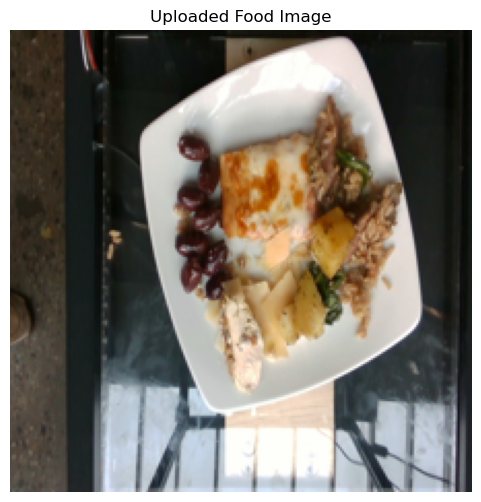

=== HASIL PREDIKSI NUTRISI ===
Calories : 290.01 kcal
Fat       : 14.25 g
Carb      : 19.42 g
Protein   : 20.86 g


In [6]:
image_path = "contoh_makanan.png"

predict_nutrition(image_path)